### 1. Setup e Imports

In [1]:
import numpy as np
import pandas as pd
import sys
import os
import subprocess
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from sae.models.sae import SparseAutoencoder
from sae.tools.experiment_utils import get_experiment_dir, get_metrics_dir, get_report_name
from sae.tools.naming_utils import get_checkpoint_dir, get_model_name, get_extras_id

project_root = Path('../../..').resolve()
sys.path.insert(0, str(project_root))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 5060
Memoria: 8.55 GB


In [2]:
# Configuración para visualización en PDF
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)
np.set_printoptions(linewidth=100, edgeitems=3)

os.environ['COLUMNS'] = '100'

print(" Configuración para PDF lista")

 Configuración para PDF lista


In [3]:
NAMING_META = {
    'variante': 'standard',          # Arquitectura del SAE
    'tecnica': 'p-annealing',        # P-annealing (Lp^p con p decreciente)
    'capa': 6,                       # Layer del modelo OthelloGPT
    'juegos': 100000,                # Número de partidas
    'base_path': 'C:\\Users\\Esposa\\Documents\\Repos\\sae-othello-gpt',  # Path base para checkpoints
    'experiment_base_path': os.path.abspath('../../../experiments') ,      # sae/experiments/
    'extras': {          
        'expansion': 16,
        'sparsity_coef': 3e-1,
        'epochs': 200,
        'early_stopping': False,
       'learning_rate':1e-3,
        'p_start': 1.0,
        'p_end':0.2,
        'n_sparsity_updates': 11,
        'anneal_start': 5000,
        'batch_size':2048,
        'warmup_steps': 1000,
        'sparsity_warmup_steps':2000,
        'estimated_epochs':200
    }
}

print('\n Metadata de naming:')
for key, value in NAMING_META.items():
    print(f'  {key}: {value}')


 Metadata de naming:
  variante: standard
  tecnica: p-annealing
  capa: 6
  juegos: 100000
  base_path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt
  experiment_base_path: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments
  extras: {'expansion': 16, 'sparsity_coef': 0.3, 'epochs': 200, 'early_stopping': False, 'learning_rate': 0.001, 'p_start': 1.0, 'p_end': 0.2, 'n_sparsity_updates': 11, 'anneal_start': 5000, 'batch_size': 2048, 'warmup_steps': 1000, 'sparsity_warmup_steps': 2000, 'estimated_epochs': 200}


### 2. Cargar Datos

In [4]:
n_games = 1000
n_moves = 59

In [5]:
# Cargar activaciones
activations_path = project_root / "activations" / "data" / "layer6_2000games.npy"
activations = np.load(activations_path)[:n_games * n_moves]

print(f"Activaciones del modelo:")
print(f"  Shape: {activations.shape}")
print(f"  Memoria: {activations.nbytes / (1024**2):.2f} MB")

Activaciones del modelo:
  Shape: (59000, 512)
  Memoria: 115.23 MB


In [6]:
# Cargar ground truth de BSPs
bsp_gt_path = project_root / "metrics" / "02_data" / "bsp_ground_truth_2000games.npy"
bsp_names_path = project_root / "metrics" / "02_data" / "bsp_ground_truth_2000games.names.npy"

bsp_ground_truth = np.load(bsp_gt_path)[:n_games * n_moves]
bsp_names = np.load(bsp_names_path, allow_pickle=True)

print(f"\nGround truth BSPs:")
print(f"  Shape: {bsp_ground_truth.shape}")
print(f"  Total BSPs: {len(bsp_names)}")


Ground truth BSPs:
  Shape: (59000, 326)
  Total BSPs: 326


### 3. Cargar SAE y Extraer Features

In [7]:
# Configuración del SAE
input_dim = 512
hidden_dim = 8192

# Construir ruta del modelo usando naming_utils
checkpoint_dir = get_checkpoint_dir(
    NAMING_META['base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos']
)
extras_id = get_extras_id(checkpoint_dir, NAMING_META['extras']) if NAMING_META.get('extras') else None

model_filename = get_model_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    'final',
    extras_id=extras_id
)
model_path = checkpoint_dir / model_filename

# Cargar modelo SAE estándar
sae = SparseAutoencoder(input_dim, hidden_dim).to(device)

checkpoint = torch.load(model_path, map_location=device, weights_only=False)
sae.load_state_dict(checkpoint['model_state_dict'])
sae.eval()

print(f"SAE cargado:")
print(f"  Path: {model_path}")
print(f"  Input: {input_dim}, Hidden: {hidden_dim}")
print(f"  Expansion: {hidden_dim/input_dim}x")

SAE cargado:
  Path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_standard\sae_p-annealing_standard\100000games\sae_standard_p-annealing_l6_100000g_ex1_final.pt
  Input: 512, Hidden: 8192
  Expansion: 16.0x


In [8]:
# Extraer features del SAE en GPU
print("Extrayendo features del SAE...")
activations_tensor = torch.from_numpy(activations).float().to(device)

with torch.no_grad():
    sae_features = sae.encode(activations_tensor)

print(f"\nFeatures SAE:")
print(f"  Shape: {sae_features.shape}")
print(f"  Device: {sae_features.device}")
sparsity = (sae_features == 0).float().mean().item()
print(f"  Sparsity: {sparsity:.2%}")
print(f"  Activaciones promedio: {sae_features.shape[1] * (1 - sparsity):.1f}")

Extrayendo features del SAE...

Features SAE:
  Shape: torch.Size([59000, 8192])
  Device: cuda:0
  Sparsity: 96.03%
  Activaciones promedio: 324.8


In [9]:
del activations_tensor 
torch.cuda.empty_cache() 

### 4. Split Train/Test y Filtrar BSPs de Piezas

In [10]:
# Split 50/50: 
n_moves = 59
n_games = 1000  # número de partidas para prueba de métricas
train_games = n_games // 2  
split_idx = train_games * n_moves  

sae_features_train = sae_features[:split_idx]
sae_features_test  = sae_features[split_idx:]

print(f"Total partidas: {n_games}")
print(f"Train: {train_games} partidas ({split_idx} activaciones)")
print(f"Test:  {n_games - train_games} partidas ({len(activations) - split_idx} activaciones)")
print(f"Train set: {sae_features_train.shape}")
print(f"Test set:  {sae_features_test.shape}")

Total partidas: 1000
Train: 500 partidas (29500 activaciones)
Test:  500 partidas (29500 activaciones)
Train set: torch.Size([29500, 8192])
Test set:  torch.Size([29500, 8192])


In [11]:
# =============================================
# CONFIGURACIÓN DE FILTRADO DE BSPs
# =============================================
USE_PLAYER   = True  # BSPs perspectiva del jugador (1 y 2)
USE_ABSOLUTE = False   # BSPs absolutas negro/blanco (B y W)
USE_STRATEGIC = False  # BSPs especiales (BSP_)

bsp_pieces_indices = []
bsp_pieces_names = []

for i, name in enumerate(bsp_names):
    include = False
    if USE_PLAYER and len(name) == 6 and name.startswith('BSP') and (name.endswith('1') or name.endswith('2')):
        include = True
    if USE_ABSOLUTE and (name.endswith('B') or name.endswith('W')):
        include = True
    if USE_STRATEGIC and name.startswith('BSP_'):
        include = True
    if include:
        bsp_pieces_indices.append(i)
        bsp_pieces_names.append(name)

bsp_pieces_indices = np.array(bsp_pieces_indices)

# Para reconstruction necesitas split train/test
bsp_gt_train_pieces = torch.from_numpy(bsp_ground_truth[:split_idx, bsp_pieces_indices]).bool().to(device)
bsp_gt_test_pieces  = torch.from_numpy(bsp_ground_truth[split_idx:, bsp_pieces_indices]).bool().to(device)

# Convertir a tensor en GPU
# Identificador del filtrado (para naming de archivos de salida)
parts = []
if USE_PLAYER: parts.append("player")
if USE_ABSOLUTE: parts.append("absolute")
if USE_STRATEGIC: parts.append("strategic")
filter_suffix = "_".join(parts) if parts else "none"

print(f"BSPs seleccionadas para Reconstruction:")
print(f"  Player: {USE_PLAYER} | Absolute: {USE_ABSOLUTE} | Strategic: {USE_STRATEGIC}")
print(f"  Total: {len(bsp_pieces_indices)}")
print(f"  Train shape: {bsp_gt_train_pieces.shape}")
print(f"  Test shape:  {bsp_gt_test_pieces.shape}")
print(f"  Device: {bsp_gt_train_pieces.device}")
print(f"  Primeras 5: {', '.join(bsp_pieces_names[:5])}")
print(f"  Últimas 5: {', '.join(bsp_pieces_names[-5:])}")
print(f"  Filter suffix: {filter_suffix}")


BSPs seleccionadas para Reconstruction:
  Player: True | Absolute: False | Strategic: False
  Total: 128
  Train shape: torch.Size([29500, 128])
  Test shape:  torch.Size([29500, 128])
  Device: cuda:0
  Primeras 5: BSPA11, BSPA12, BSPA21, BSPA22, BSPA31
  Últimas 5: BSPH62, BSPH71, BSPH72, BSPH81, BSPH82
  Filter suffix: player


### 5. Funciones GPU-Optimizadas

In [12]:
def fast_precision_score_gpu(y_true, y_pred, eps=1e-8):
    """
    Precisión vectorizada en GPU.
    
    Args:
        y_true: Tensor (n_positions,) booleano
        y_pred: Tensor (n_positions, n_candidates) booleano
    
    Returns:
        precision_scores: Tensor (n_candidates,)
    """
    y_true_expanded = y_true.unsqueeze(1)
    
    tp = (y_true_expanded & y_pred).sum(dim=0).float()
    fp = (~y_true_expanded & y_pred).sum(dim=0).float()
    
    precision = tp / (tp + fp + eps)
    
    return precision


def fast_f1_score_gpu(y_true, y_pred, eps=1e-8):
    """
    F1 score vectorizado en GPU.
    
    Args:
        y_true: Tensor (n_positions,) booleano
        y_pred: Tensor (n_positions,) booleano  
    
    Returns:
        f1: Float
    """
    tp = (y_true & y_pred).sum().float()
    fp = (~y_true & y_pred).sum().float()
    fn = (y_true & ~y_pred).sum().float()
    
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    
    return f1.item()

print(" Funciones GPU definidas")

 Funciones GPU definidas


### 6. Fase 1: Identificar Features de Alta Precisión (GPU)

Para cada BSP, encontrar features con precisión ≥ 0.95 en el train set.

In [13]:
def identify_high_precision_features_gpu(
    sae_features_train,
    bsp_gt_train,
    f_max,
    precision_threshold=0.95,
    significance_threshold=10,
    thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    feature_batch_size=512,
    verbose=True
):
    """
    Para cada (threshold t, feature f, BSP b): determina si f es clasificador
    de alta precisión para b al threshold t.

    Criterios (igual que implementación oficial):
        - precision(f, b, t) >= precision_threshold   (default 0.95)
        - on_count(f, t)     >= significance_threshold (default 10)

    Args:
        sae_features_train:    Tensor (P, n_features) GPU
        bsp_gt_train:          Tensor (P, n_bsps) GPU, bool
        f_max:                 Tensor (n_features,) GPU — calculado FUERA para
                               garantizar identidad exacta con Fase 2
        precision_threshold:   float, default 0.95
        significance_threshold: int, mín. activaciones requeridas (default 10)
        thresholds:            lista de fracciones t ∈ [0, 1)
        feature_batch_size:    int, features por mini-batch interno

    Returns:
        hp_mask_TFB:            BoolTensor (T, n_active, n_bsps)
        active_feature_indices: LongTensor (n_active,)
    """
    n_positions, n_features = sae_features_train.shape
    n_bsps = bsp_gt_train.shape[1]
    device = sae_features_train.device

    thresholds_T = torch.tensor(thresholds, device=device)
    n_thresholds = len(thresholds_T)

    # Features vivas (f_max > 0)
    active_feature_indices = (f_max > 0).nonzero(as_tuple=True)[0]
    n_active = len(active_feature_indices)

    if verbose:
        print("=" * 60)
        print("FASE 1: IDENTIFICAR FEATURES DE ALTA PRECISIÓN")
        print("=" * 60)
        print(f"Precision threshold:     {precision_threshold}")
        print(f"Significance threshold:  >= {significance_threshold} activaciones")
        print(f"Features activas:        {n_active}/{n_features} ({n_active/n_features*100:.1f}%)")
        print(f"BSPs:                    {n_bsps}")
        print(f"Thresholds:              {thresholds}")
        print("=" * 60)

    # Thresholds absolutos: thresh_TF[t, f] = t * f_max[f]
    active_f_max  = f_max[active_feature_indices]           # (n_active,)
    thresholds_TF = thresholds_T[:, None] * active_f_max   # (T, n_active)

    # Acumuladores sobre todo el train set
    on_count_TF  = torch.zeros(n_thresholds, n_active, device=device)
    tp_count_TFB = torch.zeros(n_thresholds, n_active, n_bsps, device=device)

    bsp_float_PB = bsp_gt_train.float()  # (P, B)

    n_iters = (n_active + feature_batch_size - 1) // feature_batch_size

    for fi in tqdm(range(n_iters), desc="Fase 1"):
        f_start = fi * feature_batch_size
        f_end   = min(f_start + feature_batch_size, n_active)

        global_idx = active_feature_indices[f_start:f_end]
        acts_PF    = sae_features_train[:, global_idx]     # (P, bs)
        thresh_TF  = thresholds_TF[:, f_start:f_end]      # (T, bs)

        # active_TFP[t, f, p] = True si acts[p,f] > thresh[t,f]
        active_TFP = acts_PF.T.unsqueeze(0) > thresh_TF.unsqueeze(2)  # (T, bs, P)

        # Conteo de activaciones por (threshold, feature)
        on_count_TF[:, f_start:f_end] += active_TFP.sum(dim=2).float()

        # True positives: f activa Y BSP verdadera
        # tp[t, f, b] = Σ_p active[t,f,p] * bsp[p,b]
        tp_count_TFB[:, f_start:f_end, :] += torch.einsum(
            'tfp,pb->tfb', active_TFP.float(), bsp_float_PB
        )

    # Precisión: tp / on_count
    eps = 1e-8
    precision_TFB = tp_count_TFB / (on_count_TF.unsqueeze(2) + eps)  # (T, F, B)

    # Máscara: alta precisión AND significancia suficiente
    sig_mask_TF1 = (on_count_TF >= significance_threshold).unsqueeze(2)  # (T, F, 1)
    hp_mask_TFB  = (precision_TFB >= precision_threshold) & sig_mask_TF1  # (T, F, B)

    if verbose:
        hp_per_t = hp_mask_TFB.sum(dim=(1, 2))  # (T,)
        hp_per_b = hp_mask_TFB.sum(dim=1)        # (T, B)
        best_t   = hp_per_t.argmax().item()
        print(f"\nPares (feature, BSP) de alta precisión por threshold:")
        for i, t in enumerate(thresholds):
            marker = " ← más pares" if i == best_t else ""
            print(f"  t={t:.1f}: {hp_per_t[i].item():5d} pares{marker}")
        print(f"\nFeatures HP por BSP en t={thresholds[best_t]:.1f}:")
        print(f"  Media:             {hp_per_b[best_t].float().mean():.1f}")
        print(f"  Máx:               {hp_per_b[best_t].max().item()}")
        print(f"  BSPs sin features: {(hp_per_b[best_t] == 0).sum().item()}")

    return hp_mask_TFB, active_feature_indices

print("✓ Fase 1 rediseñada: umbral de significancia (≥10) + estructura (T, F, B)")

✓ Fase 1 rediseñada: umbral de significancia (≥10) + estructura (T, F, B)


In [14]:
THRESHOLDS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# f_max calculado UNA SOLA VEZ aquí — se pasa a Fase 1 y Fase 2
f_max = sae_features_train.max(dim=0)[0]  # (n_features,)
print(f"f_max calculado: {(f_max > 0).sum().item()} features activas de {f_max.shape[0]}")

start_time = time.time()

hp_mask_TFB, active_feature_indices = identify_high_precision_features_gpu(
    sae_features_train,
    bsp_gt_train_pieces,
    f_max,
    precision_threshold=0.95,
    significance_threshold=10,
    thresholds=THRESHOLDS,
    feature_batch_size=512,
    verbose=True
)

phase1_time = time.time() - start_time

print(f"\nTiempo Fase 1: {phase1_time:.2f} seg")
print(f"hp_mask_TFB shape: {hp_mask_TFB.shape}  (T, n_active, n_bsps)")

f_max calculado: 2992 features activas de 8192
FASE 1: IDENTIFICAR FEATURES DE ALTA PRECISIÓN
Precision threshold:     0.95
Significance threshold:  >= 10 activaciones
Features activas:        2992/8192 (36.5%)
BSPs:                    128
Thresholds:              [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


Fase 1: 100%|██████████| 6/6 [00:00<00:00, 505.03it/s]



Pares (feature, BSP) de alta precisión por threshold:
  t=0.0:   551 pares
  t=0.1:   468 pares
  t=0.2:   404 pares
  t=0.3:   452 pares
  t=0.4:   529 pares
  t=0.5:   622 pares
  t=0.6:   677 pares ← más pares
  t=0.7:   676 pares
  t=0.8:   660 pares
  t=0.9:   490 pares

Features HP por BSP en t=0.6:
  Media:             5.3
  Máx:               59
  BSPs sin features: 6

Tiempo Fase 1: 0.26 seg
hp_mask_TFB shape: torch.Size([10, 2992, 128])  (T, n_active, n_bsps)


### 7. Fase 2: Reconstruir Tableros en Test Set (GPU)

In [15]:
def reconstruct_boards_gpu(
    sae_features_test,
    bsp_gt_test,
    hp_mask_TFB,
    active_feature_indices,
    f_max,
    thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    verbose=True
):
    """
    Fase 2: barrido simultáneo de thresholds T → toma el mejor F1.

    Para cada threshold t:
      1. Binarizar features de test: active[p, f] = acts[p, f] > t * f_max[f]
      2. Predicción por (posición, BSP):
             predict[p, b] = OR_f ( active[p,f] AND hp_mask[t, f, b] )
             implementado como: (active_PF @ hp_FB) > 0
      3. F1 global micro-averaged (acumula TP/FP/FN sobre todas las posiciones y BSPs)
    
    Retorna el max F1 sobre todos los thresholds (Eq. 5 del paper: max_t).

    Args:
        sae_features_test:      Tensor (P, n_features) GPU
        bsp_gt_test:            Tensor (P, n_bsps) GPU, bool
        hp_mask_TFB:            BoolTensor (T, n_active, n_bsps) de Fase 1
        active_feature_indices: LongTensor (n_active,) de Fase 1
        f_max:                  Tensor (n_features,) GPU — MISMO objeto que Fase 1
        thresholds:             lista de fracciones (debe coincidir con Fase 1)

    Returns:
        best_f1:          float, max F1 sobre thresholds
        best_threshold:   float, threshold óptimo
        f1_per_threshold: np.array (T,), F1 por threshold
    """
    device = sae_features_test.device
    n_thresholds = len(thresholds)
    thresholds_T = torch.tensor(thresholds, device=device)

    # Activaciones del test solo para features activas
    test_active_PF = sae_features_test[:, active_feature_indices]  # (P, n_active)
    active_f_max   = f_max[active_feature_indices]                  # (n_active,)

    gt_PB = bsp_gt_test.bool()  # (P, B)
    eps   = 1e-8

    f1_scores   = torch.zeros(n_thresholds, device=device)
    precision_T = torch.zeros(n_thresholds, device=device)
    recall_T    = torch.zeros(n_thresholds, device=device)

    if verbose:
        print("=" * 60)
        print("FASE 2: RECONSTRUCCIÓN — BARRIDO DE THRESHOLDS")
        print("=" * 60)
        print(f"{'t':>5}  {'F1':>8}  {'P':>8}  {'R':>8}  {'TP':>8}  {'FP':>8}  {'FN':>8}")
        print("-" * 60)

    for t_idx in range(n_thresholds):
        t = thresholds[t_idx]

        # Threshold absoluto por feature: t * f_max[f]
        abs_thresh_F = thresholds_T[t_idx] * active_f_max  # (n_active,)

        # Binarizar features en test
        active_PF = test_active_PF > abs_thresh_F.unsqueeze(0)  # (P, n_active)

        # predict[p, b] = any( active[p,f] AND hp[t,f,b] )
        # = (active_PF.float() @ hp_mask[t].float()) > 0
        hp_FB          = hp_mask_TFB[t_idx].float()              # (n_active, B)
        predictions_PB = (active_PF.float() @ hp_FB) > 0         # (P, B)

        # Métricas globales micro-averaged
        tp = (predictions_PB &  gt_PB).sum().float()
        fp = (predictions_PB & ~gt_PB).sum().float()
        fn = (~predictions_PB & gt_PB).sum().float()

        p  = tp / (tp + fp + eps)
        r  = tp / (tp + fn + eps)
        f1 = 2 * p * r / (p + r + eps)

        f1_scores[t_idx]   = f1
        precision_T[t_idx] = p
        recall_T[t_idx]    = r

        if verbose:
            print(f"{t:>5.1f}  {f1.item():>8.4f}  {p.item():>8.4f}  {r.item():>8.4f}"
                  f"  {tp.item():>8.0f}  {fp.item():>8.0f}  {fn.item():>8.0f}")

    best_idx       = f1_scores.argmax().item()
    best_f1        = f1_scores[best_idx].item()
    best_threshold = thresholds[best_idx]

    if verbose:
        print("=" * 60)
        print(f"Mejor threshold: t={best_threshold:.1f}")
        print(f"Reconstruction Score (max_t F1): {best_f1:.4f}")
        print("=" * 60)

    return best_f1, best_threshold, f1_scores.cpu().numpy()

print("✓ Fase 2 rediseñada: barrido T simultáneo + F1 global micro-averaged + max_t")

✓ Fase 2 rediseñada: barrido T simultáneo + F1 global micro-averaged + max_t


In [16]:
start_time = time.time()

reconstruction_score, best_threshold, f1_per_threshold = reconstruct_boards_gpu(
    sae_features_test,
    bsp_gt_test_pieces,
    hp_mask_TFB,
    active_feature_indices,
    f_max,           # mismo tensor calculado antes de Fase 1
    thresholds=THRESHOLDS,
    verbose=True
)

phase2_time = time.time() - start_time
total_time  = phase1_time + phase2_time

print(f"\nTiempo Fase 2: {phase2_time:.2f} seg")
print(f"Tiempo total:  {total_time:.2f} seg ({total_time/60:.2f} min)")

FASE 2: RECONSTRUCCIÓN — BARRIDO DE THRESHOLDS
    t        F1         P         R        TP        FP        FN
------------------------------------------------------------
  0.0    0.0212    0.9770    0.0107     10750       253    992250
  0.1    0.0197    0.9842    0.0099      9964       160    993036
  0.2    0.0363    0.9809    0.0185     18567       362    984433
  0.3    0.1082    0.9825    0.0572     57406      1025    945594
  0.4    0.1164    0.9868    0.0618     62013       827    940987
  0.5    0.0933    0.9888    0.0490     49110       554    953890
  0.6    0.0680    0.9899    0.0352     35289       359    967711
  0.7    0.0420    0.9921    0.0214     21506       171    981494
  0.8    0.0255    0.9926    0.0129     12942        97    990058
  0.9    0.0160    0.9977    0.0080      8072        19    994928
Mejor threshold: t=0.4
Reconstruction Score (max_t F1): 0.1164

Tiempo Fase 2: 0.08 seg
Tiempo total:  0.34 seg (0.01 min)


### 8. Análisis de Resultados

BARRIDO DE THRESHOLDS — F1 POR THRESHOLD
t=0.0: F1=0.0212
t=0.1: F1=0.0197
t=0.2: F1=0.0363
t=0.3: F1=0.1082
t=0.4: F1=0.1164 ← MEJOR
t=0.5: F1=0.0933
t=0.6: F1=0.0680
t=0.7: F1=0.0420
t=0.8: F1=0.0255
t=0.9: F1=0.0160


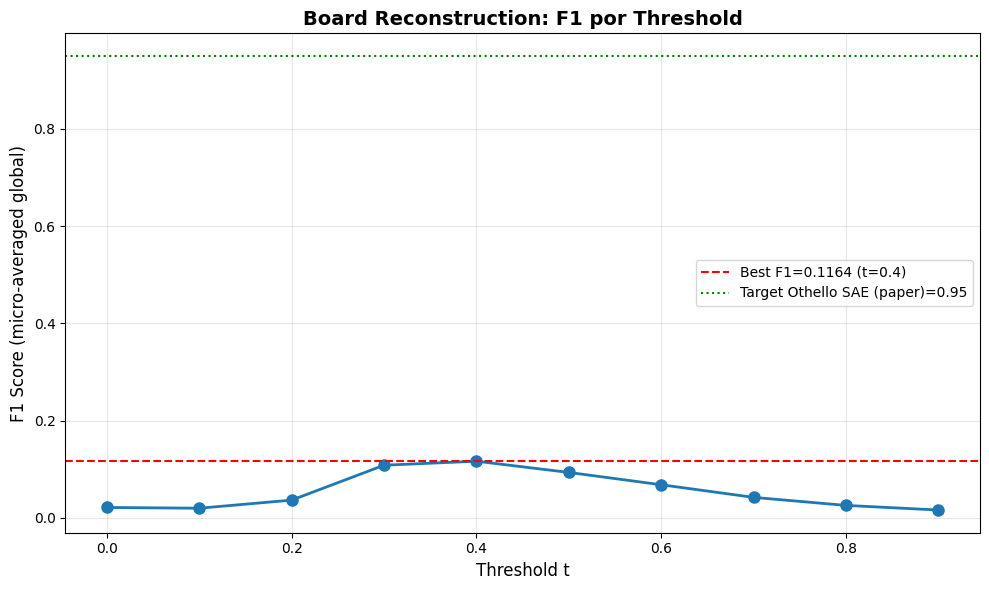


✓ Threshold óptimo: t=0.4
✓ Reconstruction Score: 0.1164


In [17]:
print("=" * 60)
print("BARRIDO DE THRESHOLDS — F1 POR THRESHOLD")
print("=" * 60)
for i, (t, f1) in enumerate(zip(THRESHOLDS, f1_per_threshold)):
    marker = " ← MEJOR" if i == f1_per_threshold.argmax() else ""
    print(f"t={t:.1f}: F1={f1:.4f}{marker}")
print("=" * 60)

plt.figure(figsize=(10, 6))
plt.plot(THRESHOLDS, f1_per_threshold, marker='o', linewidth=2, markersize=8)
plt.axhline(y=reconstruction_score, color='r', linestyle='--',
            label=f'Best F1={reconstruction_score:.4f} (t={best_threshold:.1f})')
plt.axhline(y=0.95, color='g', linestyle=':', label='Target Othello SAE (paper)=0.95')
plt.xlabel('Threshold t', fontsize=12)
plt.ylabel('F1 Score (micro-averaged global)', fontsize=12)
plt.title('Board Reconstruction: F1 por Threshold', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n✓ Threshold óptimo: t={best_threshold:.1f}")
print(f"✓ Reconstruction Score: {reconstruction_score:.4f}")

In [18]:
# Estadísticas sobre features de alta precisión por BSP
hp_per_bsp = hp_mask_TFB.sum(dim=1)  # (T, n_bsps)
best_t_idx = torch.tensor(f1_per_threshold).argmax().item()
n_features_per_bsp = hp_per_bsp[best_t_idx].cpu().numpy()

print("="*60)
print("ESTADÍSTICAS - FEATURES POR BSP")
print("="*60)
print(f"Total BSPs: {len(n_features_per_bsp)}")
print(f"Features promedio por BSP: {np.mean(n_features_per_bsp):.1f}")
print(f"Features mediana por BSP: {np.median(n_features_per_bsp):.1f}")
print(f"BSPs con 0 features: {np.sum(n_features_per_bsp == 0)}")
print(f"BSPs con 1+ features: {np.sum(n_features_per_bsp > 0)}")
print(f"BSPs con 5+ features: {np.sum(n_features_per_bsp >= 5)}")
print(f"BSPs con 10+ features: {np.sum(n_features_per_bsp >= 10)}")
print(f"Max features en una BSP: {np.max(n_features_per_bsp)}")
print("="*60)

ESTADÍSTICAS - FEATURES POR BSP
Total BSPs: 128
Features promedio por BSP: 4.1
Features mediana por BSP: 2.0
BSPs con 0 features: 20
BSPs con 1+ features: 108
BSPs con 5+ features: 25
BSPs con 10+ features: 16
Max features en una BSP: 41


In [19]:
# Comparación con resultados del paper
print("="*60)
print("COMPARACIÓN CON PAPER (Karvonen et al., NeurIPS 2024)")
print("="*60)
print(f"{'Modelo':<20} {'Reconstruction':<15}")
print("-"*60)
print(f"{'SAE random':<20} {'0.08':<15}")
print(f"{'SAE trained (paper)':<20} {'0.95':<15} ← Objetivo")
print(f"{'Linear probe':<20} {'0.99':<15}")
print(f"{'Nuestro SAE':<20} {reconstruction_score:<15.4f} ← Resultado")
print("="*60)

if reconstruction_score >= 0.90:
    print("\n✓ Excelente: Muy cercano al objetivo del paper")
elif reconstruction_score >= 0.80:
    print("\n Bueno: Por encima de random pero debajo del objetivo")
else:
    print("\n Bajo: Revisar implementación o entrenamiento del SAE")

COMPARACIÓN CON PAPER (Karvonen et al., NeurIPS 2024)
Modelo               Reconstruction 
------------------------------------------------------------
SAE random           0.08           
SAE trained (paper)  0.95            ← Objetivo
Linear probe         0.99           
Nuestro SAE          0.1164          ← Resultado

 Bajo: Revisar implementación o entrenamiento del SAE


### 9. Guardar Resultados

In [20]:
results = {
    'reconstruction_score': reconstruction_score,
    'best_threshold': best_threshold,
    'f1_per_threshold': f1_per_threshold,
    'thresholds': np.array(THRESHOLDS),
    'phase1_time_seconds': phase1_time,
    'phase2_time_seconds': phase2_time,
    'total_time_seconds': total_time,
    'bsp_names': bsp_pieces_names,
}

metrics_dir = get_metrics_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)
output_path = metrics_dir / f"reconstruction_{filter_suffix}.npz"
np.savez(output_path, **results)

print(f"✓ Resultados guardados en: {output_path}")
print(f"\nContenido:")
print(f"  reconstruction_score: {reconstruction_score:.4f}")
print(f"  best_threshold:       {best_threshold:.1f}")
print(f"  f1_per_threshold:     {f1_per_threshold}")

# Comparación con el paper
print()
print("=" * 60)
print("COMPARACIÓN CON PAPER (Karvonen et al., NeurIPS 2024)")
print("=" * 60)
print(f"{'Modelo':<25} {'Reconstruction':>14}")
print("-" * 40)
print(f"{'SAE random':<25} {'0.08':>14}")
print(f"{'SAE trained (paper)':<25} {'0.95':>14}  ← Objetivo Othello")
print(f"{'Linear probe':<25} {'0.99':>14}")
print(f"{'Nuestro SAE':<25} {reconstruction_score:>14.4f}  ← Resultado")
print("=" * 60)

if reconstruction_score >= 0.90:
    print("\n✓ Excelente: Muy cercano al objetivo del paper")
elif reconstruction_score >= 0.50:
    print("\n~ Moderado: Por encima de random, revisar SAE")
else:
    print("\n✗ Bajo: Revisar entrenamiento del SAE o calidad de las activaciones")

✓ Resultados guardados en: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\100000games\ex1\metrics\reconstruction_player.npz

Contenido:
  reconstruction_score: 0.1164
  best_threshold:       0.4
  f1_per_threshold:     [0.02120309 0.01966985 0.03633716 0.10816718 0.11636457 0.09330612 0.0679518  0.04197616 0.0254754
 0.01596691]

COMPARACIÓN CON PAPER (Karvonen et al., NeurIPS 2024)
Modelo                    Reconstruction
----------------------------------------
SAE random                          0.08
SAE trained (paper)                 0.95  ← Objetivo Othello
Linear probe                        0.99
Nuestro SAE                       0.1164  ← Resultado

✗ Bajo: Revisar entrenamiento del SAE o calidad de las activaciones


In [21]:
import subprocess
from pathlib import Path
from sae.tools.experiment_utils import get_report_name

output_dir = get_metrics_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)

pdf_name = get_report_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    f'reconstruction_{filter_suffix}',
    extras_id=extras_id
)

notebook_name = 'reconstruction_sae_standar2.ipynb'
notebook_abs = str(Path('.').resolve() / notebook_name)
output_path = output_dir / pdf_name

print(f' Generando PDF con Quarto...')
print(f' Archivo de salida: {output_path}')

result = subprocess.run(
    f'quarto render {notebook_abs} --to pdf --output-dir "{output_dir}" --output {pdf_name}',
    shell=True,
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(f' PDF generado exitosamente: {output_path}')
else:
    print(f' Error al generar PDF:')
    print(result.stderr)

 Generando PDF con Quarto...
 Archivo de salida: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\100000games\ex1\metrics\sae_standard_p-annealing_l6_100000g_ex1_reconstruction_player.pdf
 PDF generado exitosamente: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\100000games\ex1\metrics\sae_standard_p-annealing_l6_100000g_ex1_reconstruction_player.pdf
